In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

In [2]:
COLORS = {"dense": "#E24B4A", "medium": "#EF9F27", "sparse": "#1D9E75"}
RIG_COLORS = {"det": "#378ADD", "fuzzy": "#9F77DD"}

In [4]:
df = pd.read_csv('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/targeted_sdp_benchmark_collected.csv')

In [5]:
df.head(20)

,Network,N_Nodes,Target_Bucket,Target_Node,Target_Value,Exact_SDP,Exact_Time_sec,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,Absolute_Error
0,voting,17,0.5,Class,republican,0.534074,0.004503,0.526407,0.000536,2.654223,7.666511e-03
1,voting,17,0.6,Class,republican,0.644603,0.004499,0.650143,0.000505,2.578761,5.540025e-03
2,voting,17,0.7,Class,republican,0.652704,0.004866,0.641957,0.000488,2.685983,1.074651e-02
3,voting,17,0.8,Class,republican,0.790059,0.005807,0.780293,0.000547,2.632378,9.766015e-03
4,voting,17,0.9,Class,republican,0.864120,0.004467,0.863643,0.000260,2.578115,4.767049e-04
5,voting,17,1.0,Class,republican,0.975740,0.004742,0.974514,0.000028,2.593402,1.225516e-03
6,chess,36,0.4,skach,t,0.426748,0.048160,0.427971,0.000578,3.299545,1.223340e-03
7,chess,36,0.5,skach,t,0.540559,0.020667,0.554829,0.000300,3.291807,1.426997e-02
8,chess,36,0.6,skach,t,0.607173,0.009554,0.599371,0.000607,3.841575,7.801786e-03
9,chess,36,0.7,skach,t,0.680555,0.028013,0.665571,0.000482,3.667373,1.498381e-02


In [6]:
COLORS = {}
# pick a different color for each number of nodes
for num_nodes in df["N_Nodes"].unique():
    COLORS[num_nodes] = np.random.rand(3,)

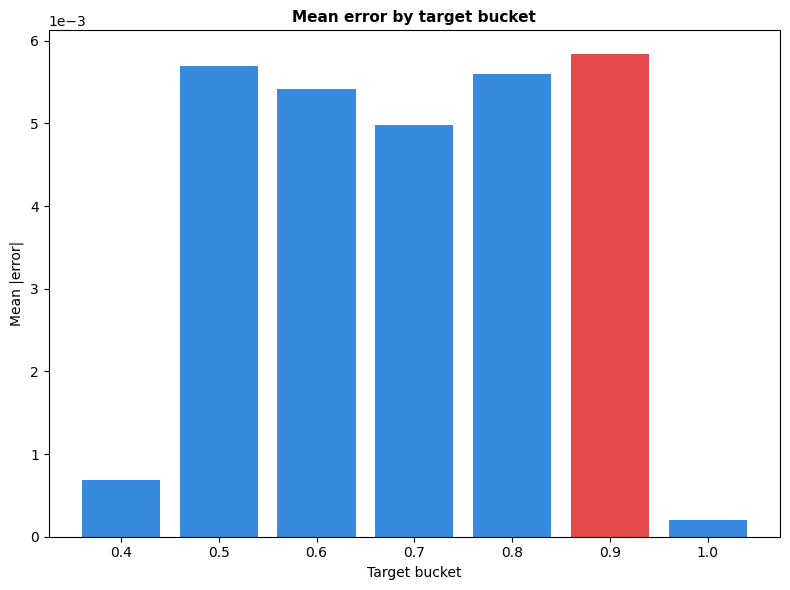

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

g_bkt = df.groupby("Target_Bucket")["Absolute_Error"].mean()
bar_colors = ["#E24B4A" if v == g_bkt.max() else "#378ADD" for v in g_bkt.values]
ax.bar([str(b) for b in g_bkt.index], g_bkt.values,
       color=bar_colors, edgecolor="none")

ax.set_title("Mean error by target bucket", fontsize=11, fontweight="bold")
ax.set_xlabel("Target bucket")
ax.set_ylabel("Mean |error|")
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))

plt.tight_layout()
plt.savefig("benchmark_mean_error_by_target_bucket.png", dpi=150, bbox_inches="tight")
plt.show()

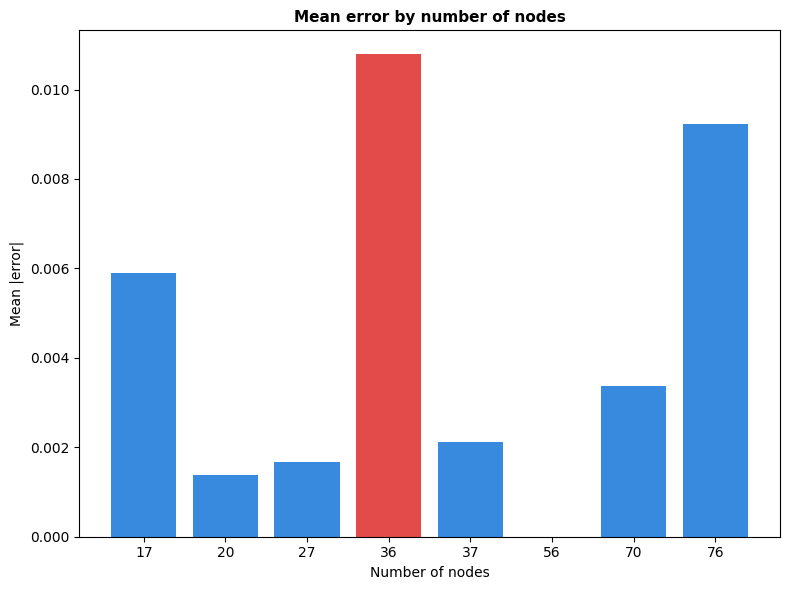

In [8]:
# error by number of nodes

fig, ax = plt.subplots(figsize=(8, 6))
g_nodes = df.groupby("N_Nodes")["Absolute_Error"].mean()
bar_colors = ["#E24B4A" if v == g_nodes.max() else "#378ADD" for v in g_nodes.values]
ax.bar([str(b) for b in g_nodes.index], g_nodes.values,
       color=bar_colors, edgecolor="none")
ax.set_title("Mean error by number of nodes", fontsize=11, fontweight="bold")
ax.set_xlabel("Number of nodes")
ax.set_ylabel("Mean |error|")

plt.tight_layout()
plt.savefig("benchmark_mean_error_by_num_nodes.png", dpi=150, bbox_inches="tight")
plt.show()

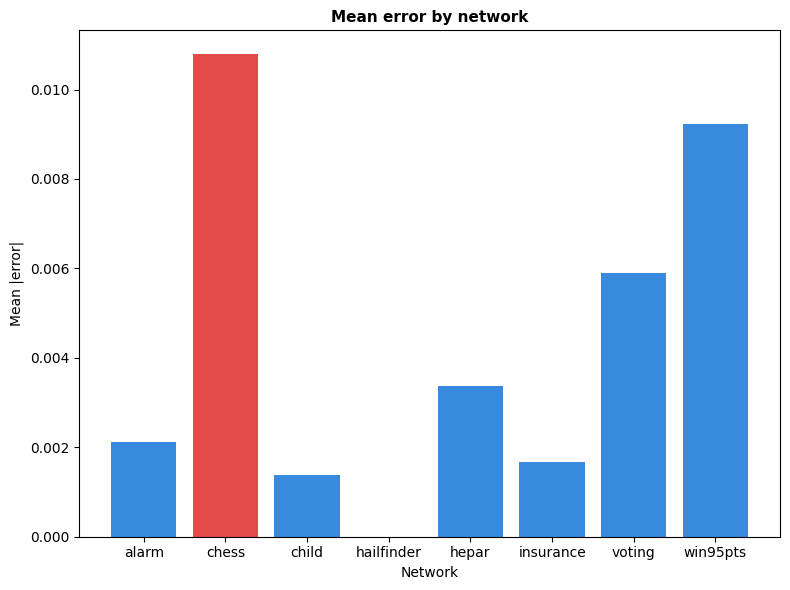

In [10]:
# error by network name
fig, ax = plt.subplots(figsize=(8, 6))
g_name = df.groupby("Network")["Absolute_Error"].mean()
bar_colors = ["#E24B4A" if v == g_name.max() else "#378ADD" for v in g_name.values]
ax.bar(g_name.index, g_name.values,
       color=bar_colors, edgecolor="none")
ax.set_title("Mean error by network", fontsize=11, fontweight="bold")
ax.set_xlabel("Network")
ax.set_ylabel("Mean |error|")
plt.tight_layout()
plt.savefig("benchmark_mean_error_by_network.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
bn_entropies = pd.read_csv('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/bn_entropies.csv')
bn_entropies = bn_entropies.rename(columns={"Model": "Network"})
bn_entropies.head()

,Network,Entropy (nats)
0,voting,8.408815
1,chess,14.331518
2,alarm,10.437962
3,child,12.195767
4,insurance,13.063305


In [27]:
# plot error by entropy

merged = pd.merge(df, bn_entropies, on="Network")
merged.head()



,Network,N_Nodes,Target_Bucket,Target_Node,Target_Value,Exact_SDP,Exact_Time_sec,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,Absolute_Error,Entropy (nats)
0,voting,17,0.5,Class,republican,0.534074,0.004503,0.526407,0.000536,2.654223,0.007667,8.408815
1,voting,17,0.6,Class,republican,0.644603,0.004499,0.650143,0.000505,2.578761,0.005540,8.408815
2,voting,17,0.7,Class,republican,0.652704,0.004866,0.641957,0.000488,2.685983,0.010747,8.408815
3,voting,17,0.8,Class,republican,0.790059,0.005807,0.780293,0.000547,2.632378,0.009766,8.408815
4,voting,17,0.9,Class,republican,0.864120,0.004467,0.863643,0.000260,2.578115,0.000477,8.408815


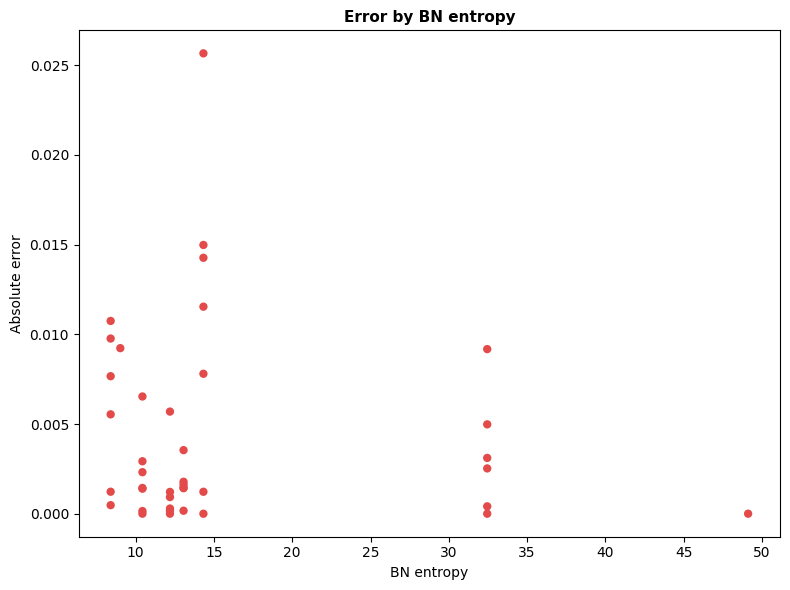

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(merged["Entropy (nats)"], merged["Absolute_Error"], color="#E24B4A", edgecolor="none")
ax.set_title("Error by BN entropy", fontsize=11, fontweight="bold")
ax.set_xlabel("BN entropy")
ax.set_ylabel("Absolute error")
plt.tight_layout()
plt.savefig("benchmark_error_by_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

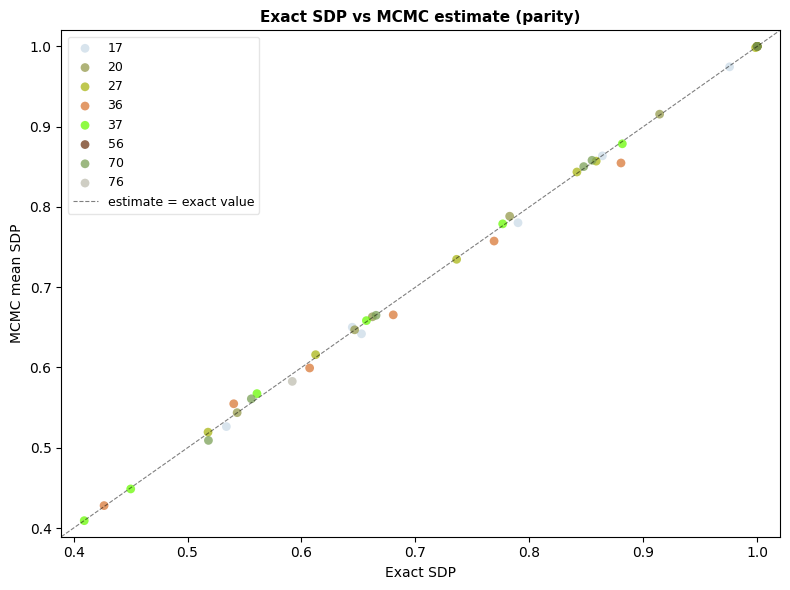

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))

for num_nodes, grp in df.groupby("N_Nodes"):
    ax.scatter(grp["Exact_SDP"], grp["MCMC_Mean_SDP"],
               label=num_nodes, color=COLORS[num_nodes], alpha=0.75, s=40, edgecolors="none")

lims = [df[["Exact_SDP", "MCMC_Mean_SDP"]].min().min() - 0.02,
        df[["Exact_SDP", "MCMC_Mean_SDP"]].max().max() + 0.02]

ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5, label="estimate = exact value")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Exact SDP vs MCMC estimate (parity)", fontsize=11, fontweight="bold")
ax.set_xlabel("Exact SDP")
ax.set_ylabel("MCMC mean SDP")
ax.legend(fontsize=9, framealpha=0.5)

plt.tight_layout()
plt.savefig("benchmark_exact_vs_mcmc_parity.png", dpi=150, bbox_inches="tight")
plt.show()

# ISAMBARD

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/targeted_sdp_benchmark_full_isambard_medium_nets_bigger_memory.csv')

In [3]:
df = pd.read_csv('/home/joao/Desktop/UFMG/PhD/code/explaining-BN/src/targeted_sdp_benchmark_full_isambard_medium_nets_seed_true.csv')

In [4]:
df.columns

Index(['Network', 'N_Nodes', 'Target_Bucket', 'H_Ratio', 'N_Hidden',
       'Target_Node', 'Target_Value', 'Status', 'Wall_Hits', 'Attempts_OK',
       'SDP_Failures', 'Exact_SDP', 'Exact_Time_sec', 'Exact_Mem_MB_Python',
       'Exact_Mem_MB_RSS', 'Max_Partition_Size', 'Max_Tensor_Size',
       'MCMC_Mean_SDP', 'MCMC_Variance', 'MCMC_Avg_Time_sec',
       'MCMC_Mem_MB_Python', 'MCMC_Mem_MB_RSS', 'Absolute_Error'],
      dtype='object')

In [5]:
df.head()

,Network,N_Nodes,Target_Bucket,H_Ratio,N_Hidden,Target_Node,Target_Value,Status,Wall_Hits,Attempts_OK,...,Exact_Mem_MB_Python,Exact_Mem_MB_RSS,Max_Partition_Size,Max_Tensor_Size,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,MCMC_Mem_MB_Python,MCMC_Mem_MB_RSS,Absolute_Error
0,child,20,0.4,0.1,1,Sick,no,BUCKET_NOT_FOUND,0,556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,child,20,0.5,0.1,1,Sick,no,OK,0,556,...,0.095974,0.0,1.0,3.0,0.5318,0.000144,0.572469,0.172737,0.0,0.006800
2,child,20,0.7,0.1,1,Sick,no,OK,0,556,...,0.099247,0.0,1.0,2.0,0.6497,0.000202,0.841233,0.278015,0.0,0.000490
3,child,20,0.8,0.1,1,Sick,no,BUCKET_NOT_FOUND,0,556,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,child,20,0.9,0.1,1,Sick,no,OK,0,556,...,0.101345,0.0,1.0,6.0,0.9243,0.000093,1.955989,0.255314,0.0,0.000394


In [6]:
normalized_entropies = {'alarm': 0.436798168407322,
 'child': 0.9392924713977061,
 'insurance': 0.7382938891268565,
 'hailfinder': 1.2333028887131066,
 'hepar': 0.7348416619273956,
 'barley': 1.4195616594611,
 'win95pts': 0.3424342397315437,
 'andes': 0.5823159595252012,
 'link': 0.4188300046593287,
 'pathfinder': 0.38046773412225554}

df["Normalized_Entropy"] = df["Network"].map(normalized_entropies)

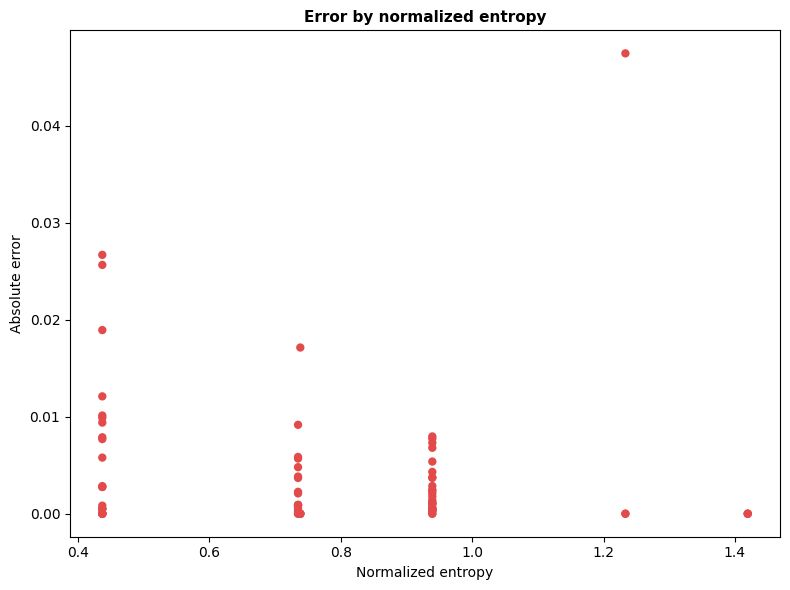

In [7]:
# Error by normalized entropy
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["Normalized_Entropy"], df["Absolute_Error"], color="#E24B4A", edgecolor="none")
ax.set_title("Error by normalized entropy", fontsize=11, fontweight="bold")
ax.set_xlabel("Normalized entropy")
ax.set_ylabel("Absolute error")
plt.tight_layout()
#plt.savefig("benchmark_error_by_normalized_entropy.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
df.Absolute_Error.describe()

count    79.000000
mean      0.004033
std       0.007300
min       0.000000
25%       0.000105
50%       0.001039
75%       0.005090
max       0.047482
Name: Absolute_Error, dtype: float64

In [9]:
# top 10 biggest erros cases
df.sort_values("Absolute_Error", ascending=False).head(10)

,Network,N_Nodes,Target_Bucket,H_Ratio,N_Hidden,Target_Node,Target_Value,Status,Wall_Hits,Attempts_OK,...,Exact_Mem_MB_RSS,Max_Partition_Size,Max_Tensor_Size,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,MCMC_Mem_MB_Python,MCMC_Mem_MB_RSS,Absolute_Error,Normalized_Entropy
134,hailfinder,56,0.8,0.50,27,ScenRelAMCIN,CThruK,OK,306,492,...,15179.3750,11.0,43908480.0,0.8000,0.160000,2.425357,0.628784,0.0,0.047482,1.233303
80,alarm,37,0.7,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,78.3125,13.0,314928.0,0.7471,0.002794,0.886412,0.317085,0.0,0.026700,0.436798
87,alarm,37,0.8,0.90,32,HYPOVOLEMIA,FALSE,OK,792,8,...,3118.7500,15.0,7962624.0,0.8195,0.001850,0.936513,0.353033,0.0,0.025662,0.436798
82,alarm,37,0.9,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,12741.2500,16.0,31850496.0,0.8366,0.001558,1.131439,0.349640,0.0,0.018940,0.436798
46,insurance,27,0.9,0.50,13,Theft,False,OK,0,787,...,464.3125,12.0,1228800.0,0.9448,0.001487,1.425541,0.376667,0.0,0.017141,0.738294
81,alarm,37,0.8,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,0.0000,7.0,1296.0,0.8606,0.001601,0.867909,0.358360,0.0,0.012102,0.436798
75,alarm,37,0.8,0.50,18,HYPOVOLEMIA,FALSE,OK,1,241,...,0.0000,9.0,2592.0,0.7599,0.000696,2.747336,0.341972,0.0,0.010125,0.436798
68,alarm,37,0.7,0.25,9,HYPOVOLEMIA,FALSE,OK,0,139,...,0.0000,4.0,192.0,0.7096,0.000232,2.986143,0.333599,0.0,0.009890,0.436798
79,alarm,37,0.5,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,28204.3750,17.0,71663616.0,0.4551,0.000357,1.266520,0.333359,0.0,0.009400,0.436798
163,hepar,70,0.7,0.50,34,hepatomegaly,absent,OK,460,29,...,24069.3750,21.0,63700992.0,0.6608,0.000572,1.515652,0.490829,0.0,0.009169,0.734842


DATASET OVERVIEW
Total rows:              179
Networks covered:        6 — ['alarm', 'barley', 'child', 'hailfinder', 'hepar', 'insurance']
H_Ratios:                [0.1, 0.25, 0.5, 0.75, 0.9]
Target buckets:          [0.4, 0.5, 0.7, 0.8, 0.9, 1.0]

Status breakdown:
  OK                                    79  (44.1%)
  BUCKET_NOT_FOUND                      70  (39.1%)
  SDP_INTRACTABLE_MCMC_ONLY             30  (16.8%)

Rows per network:
  alarm           nodes=  37 | OK=24  INTRACTABLE= 0  BUCKET_NOT_FOUND= 6
  barley          nodes=  48 | OK= 3  INTRACTABLE=12  BUCKET_NOT_FOUND=15
  child           nodes=  20 | OK=28  INTRACTABLE= 0  BUCKET_NOT_FOUND= 2
  hailfinder      nodes=  56 | OK= 3  INTRACTABLE= 6  BUCKET_NOT_FOUND=20
  hepar           nodes=  70 | OK=16  INTRACTABLE= 6  BUCKET_NOT_FOUND= 8
  insurance       nodes=  27 | OK= 5  INTRACTABLE= 6  BUCKET_NOT_FOUND=19

EXACT SDP vs MCMC ACCURACY ( only)

Absolute error stats:
  min:    0.000000
  max:    0.047482
  mean:   0.0040

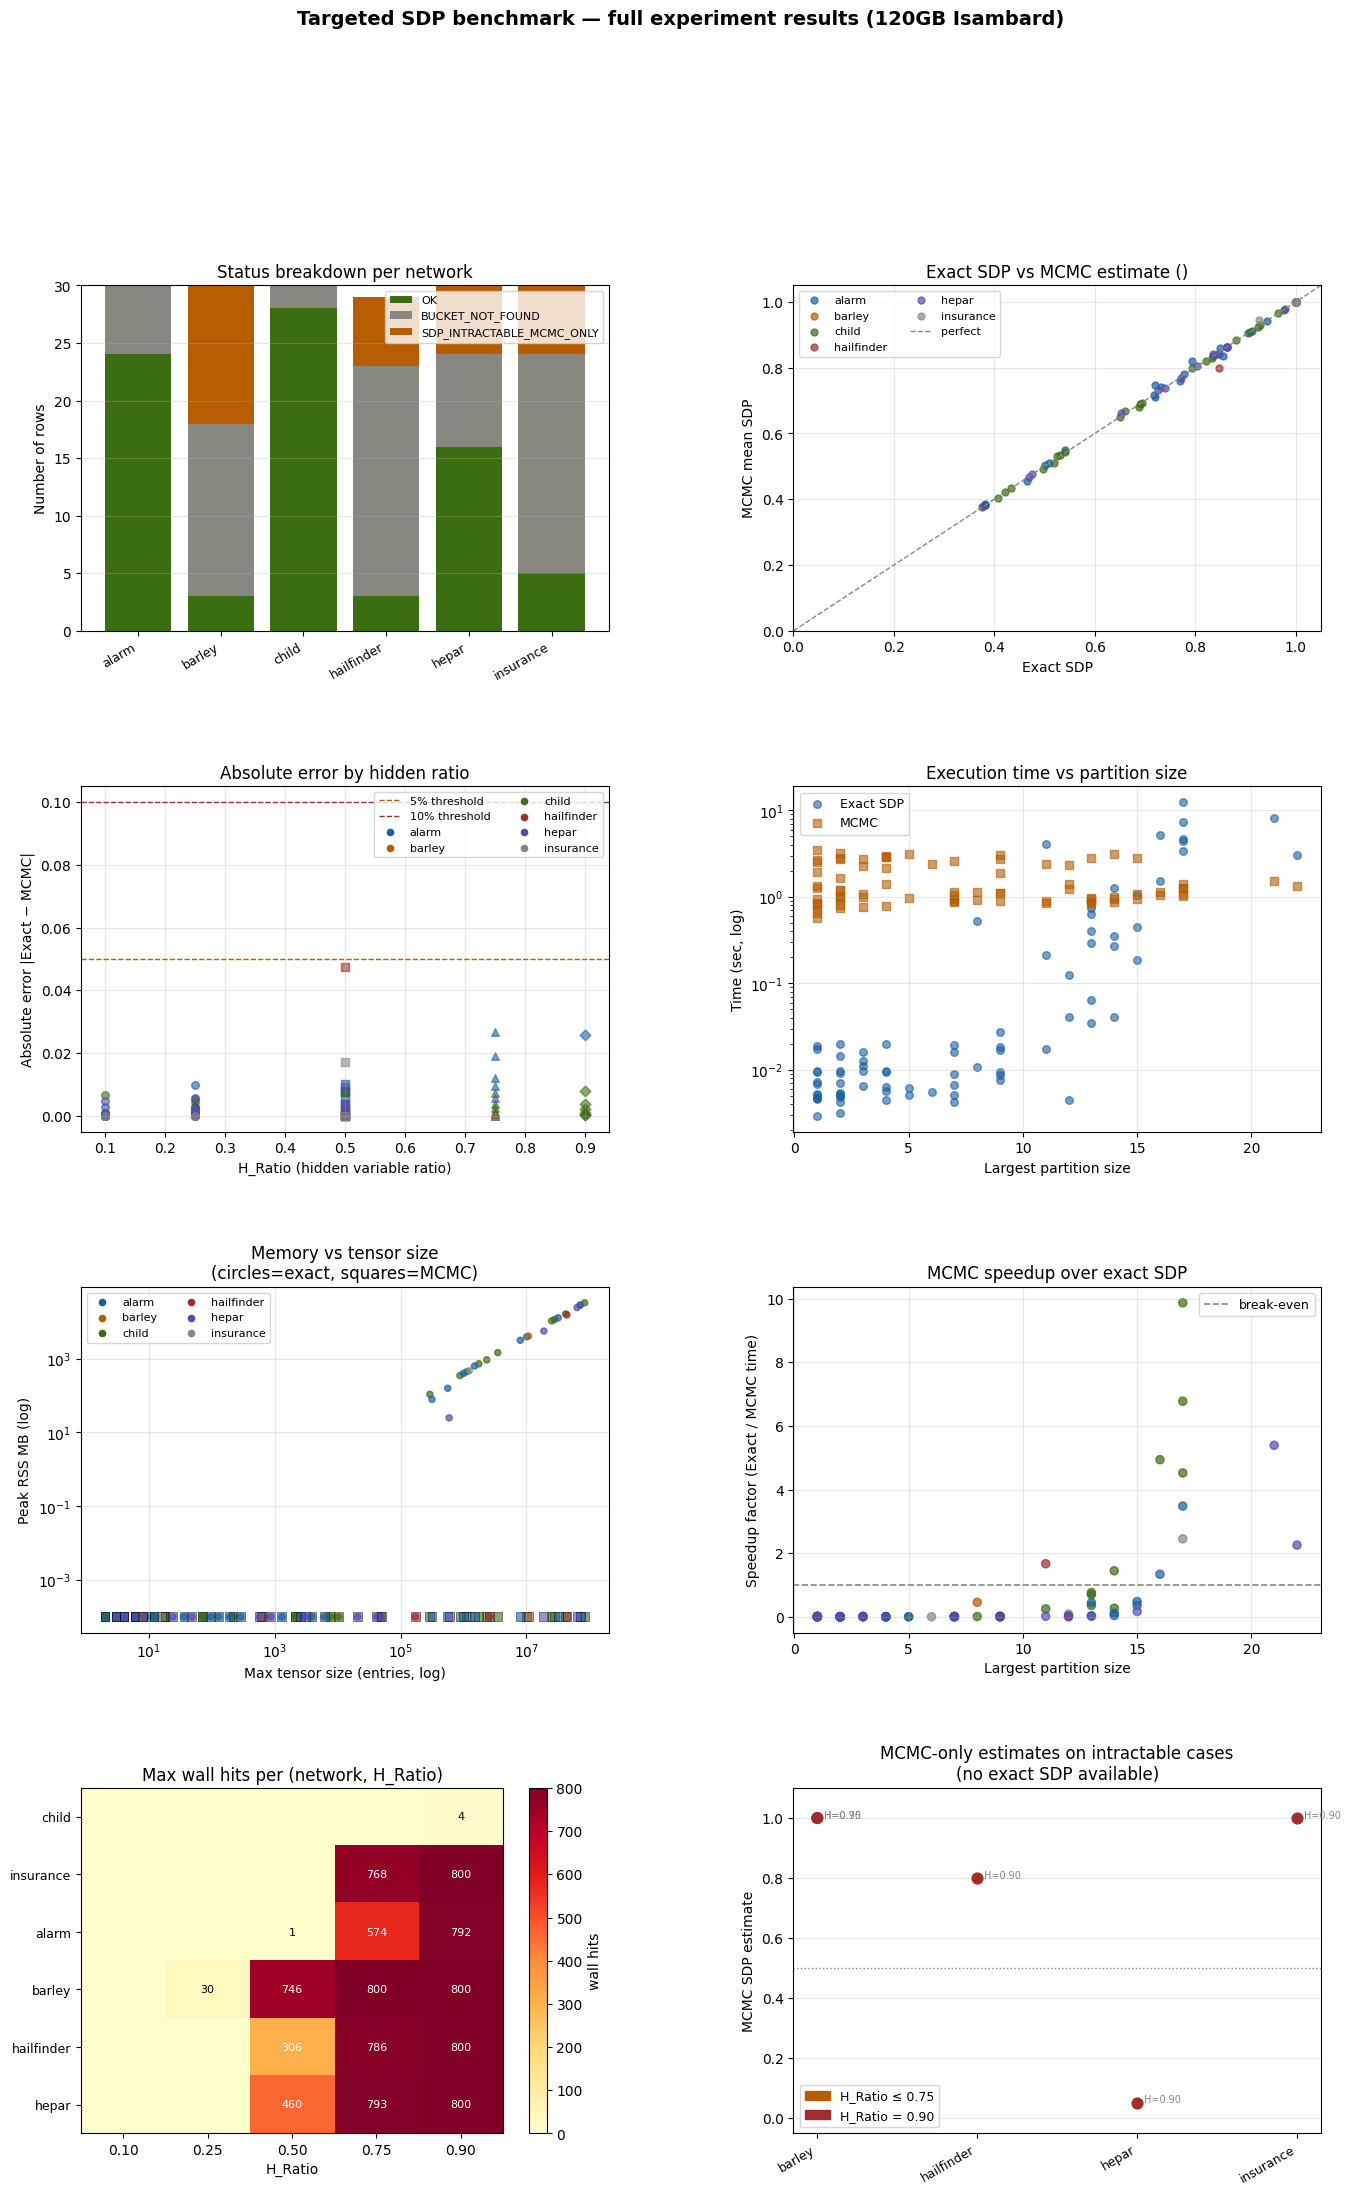

In [10]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")


BLUE   = '#185FA5'
RED    = '#A32D2D'
AMBER  = '#B85C00'
GREEN  = '#3B6D11'
PURP   = '#534AB7'
GRAY   = '#888780'
TEAL   = '#0F6E56'
CORAL  = '#993C1D'

STATUS_COLORS = {
    'OK':                        GREEN,
    'BUCKET_NOT_FOUND':          GRAY,
    'SDP_INTRACTABLE_MCMC_ONLY': AMBER,
    'EXACT_CRASHED':             RED,
    'INTRACTABLE':               RED,
}

# Derived subsets
ok        = df[df['Status'] == 'OK'].copy()
intract   = df[df['Status'] == 'SDP_INTRACTABLE_MCMC_ONLY'].copy()
has_exact = ok.copy()

# ============================================================
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"Total rows:              {len(df)}")
print(f"Networks covered:        {df['Network'].nunique()} — {sorted(df['Network'].unique())}")
print(f"H_Ratios:                {sorted(df['H_Ratio'].unique())}")
print(f"Target buckets:          {sorted(df['Target_Bucket'].unique())}")

print("\nStatus breakdown:")
for status, count in df['Status'].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {status:<35} {count:4d}  ({pct:.1f}%)")

print("\nRows per network:")
for net, grp in df.groupby('Network'):
    ok_n  = (grp['Status'] == 'OK').sum()
    int_n = (grp['Status'] == 'SDP_INTRACTABLE_MCMC_ONLY').sum()
    bnf_n = (grp['Status'] == 'BUCKET_NOT_FOUND').sum()
    print(f"  {net:<15} nodes={grp['N_Nodes'].iloc[0]:4d} | "
          f"OK={ok_n:2d}  INTRACTABLE={int_n:2d}  BUCKET_NOT_FOUND={bnf_n:2d}")

# ============================================================
print("\n" + "=" * 70)
print("EXACT SDP vs MCMC ACCURACY ( only)")
print("=" * 70)
print(f"\nAbsolute error stats:")
print(f"  min:    {ok['Absolute_Error'].min():.6f}")
print(f"  max:    {ok['Absolute_Error'].max():.6f}")
print(f"  mean:   {ok['Absolute_Error'].mean():.6f}")
print(f"  median: {ok['Absolute_Error'].median():.6f}")
print(f"  >0.05:  {(ok['Absolute_Error'] > 0.05).sum()} rows "
      f"({(ok['Absolute_Error'] > 0.05).mean()*100:.1f}%)")
print(f"  >0.10:  {(ok['Absolute_Error'] > 0.10).sum()} rows "
      f"({(ok['Absolute_Error'] > 0.10).mean()*100:.1f}%)")

print("\nAbsolute error by network:")
for net, grp in ok.groupby('Network'):
    print(f"  {net:<15} mean={grp['Absolute_Error'].mean():.4f} "
          f"max={grp['Absolute_Error'].max():.4f}  n={len(grp)}")

print("\nAbsolute error by H_Ratio:")
for hr, grp in ok.groupby('H_Ratio'):
    print(f"  H={hr:.2f}  mean={grp['Absolute_Error'].mean():.4f} "
          f"max={grp['Absolute_Error'].max():.4f}  n={len(grp)}")

# ============================================================
print("\n" + "=" * 70)
print("TIME ANALYSIS")
print("=" * 70)
print(f"\nExact SDP time (sec) :")
print(f"  min:    {ok['Exact_Time_sec'].min():.4f}")
print(f"  max:    {ok['Exact_Time_sec'].max():.4f}")
print(f"  median: {ok['Exact_Time_sec'].median():.4f}")
print(f"  mean:   {ok['Exact_Time_sec'].mean():.4f}")

print(f"\nMCMC time (sec) — all rows with MCMC:")
mcmc_rows = df[df['MCMC_Avg_Time_sec'].notna()]
print(f"  min:    {mcmc_rows['MCMC_Avg_Time_sec'].min():.4f}")
print(f"  max:    {mcmc_rows['MCMC_Avg_Time_sec'].max():.4f}")
print(f"  median: {mcmc_rows['MCMC_Avg_Time_sec'].median():.4f}")
print(f"  mean:   {mcmc_rows['MCMC_Avg_Time_sec'].mean():.4f}")

ok['speedup'] = ok['Exact_Time_sec'] / ok['MCMC_Avg_Time_sec']
crossover = ok[ok['speedup'] >= 1.0]
if len(crossover) > 0:
    print(f"\nExact SDP is slower than MCMC in {len(crossover)}/{len(ok)} OK cases")
    print(f"  Max speedup:    {ok['speedup'].max():.1f}×")
    print(f"  Crossover at partition size: "
          f"{crossover['Max_Partition_Size'].min():.0f}–{crossover['Max_Partition_Size'].max():.0f}")

# ============================================================
print("\n" + "=" * 70)
print("MEMORY ANALYSIS ")
print("=" * 70)
print(f"\nExact SDP RSS peak (MB):")
print(f"  min:    {ok['Exact_Mem_MB_RSS'].min():.2f}")
print(f"  max:    {ok['Exact_Mem_MB_RSS'].max():.2f}")
print(f"  median: {ok['Exact_Mem_MB_RSS'].median():.2f}")

print(f"\nMCMC RSS peak (MB):")
print(f"  min:    {ok['MCMC_Mem_MB_RSS'].min():.2f}")
print(f"  max:    {ok['MCMC_Mem_MB_RSS'].max():.2f}")
print(f"  median: {ok['MCMC_Mem_MB_RSS'].median():.2f}")

mem_cross = ok[ok['Exact_Mem_MB_RSS'] >= ok['MCMC_Mem_MB_RSS']]
if len(mem_cross) > 0:
    print(f"\nExact uses more memory than MCMC in {len(mem_cross)}/{len(ok)} OK cases")

# ============================================================
print("\n" + "=" * 70)
print("INTRACTABILITY ANALYSIS")
print("=" * 70)
for net, grp in df.groupby('Network'):
    total = len(grp[grp['H_Ratio'].isin([0.25, 0.5, 0.75, 0.9])])
    intract_n = (grp['Status'] == 'SDP_INTRACTABLE_MCMC_ONLY').sum()
    wall_any = (grp['Wall_Hits'] > 0).sum()
    print(f"  {net:<15} intractable rows={intract_n:2d}/{total:2d} | "
          f"rows_with_wall_hits={wall_any:2d}")

# ============================================================
print("\n" + "=" * 70)
print("WALL HITS ANALYSIS")
print("=" * 70)
wall = df[df['Wall_Hits'] > 0]
print(f"Rows with any wall hits: {len(wall)}/{len(df)}")
print(f"\nWall hits by network and H_Ratio:")
pivot = df.groupby(['Network', 'H_Ratio'])['Wall_Hits'].max().unstack()
print(pivot.to_string())

# ============================================================
print("\n" + "=" * 70)
print("MCMC VARIANCE ANALYSIS (quality check)")
print("=" * 70)
mcmc_all = df[df['MCMC_Variance'].notna()]
print(f"\nAll MCMC-evaluated rows: {len(mcmc_all)}")
print(f"  Zero variance:     {(mcmc_all['MCMC_Variance'] == 0).sum()} "
      f"(likely SDP≈1.0 or chain stuck)")
print(f"  Low variance <0.001: {(mcmc_all['MCMC_Variance'] < 0.001).sum()}")
print(f"  High variance >0.01: {(mcmc_all['MCMC_Variance'] > 0.01).sum()}")

print("\nMCMC variance by network (intractable rows):")
for net, grp in intract.groupby('Network'):
    print(f"  {net:<15} mean_var={grp['MCMC_Variance'].mean():.6f} "
          f"mean_est={grp['MCMC_Mean_SDP'].mean():.4f}")

# ============================================================
# PLOTS
# ============================================================
fig = plt.figure(figsize=(16, 24))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.35)

networks     = sorted(df['Network'].unique())
net_colors   = {n: c for n, c in zip(networks,
    [BLUE, AMBER, GREEN, RED, PURP, GRAY, TEAL, CORAL, '#444', '#999'])}
h_markers    = {0.25: 'o', 0.50: 's', 0.75: '^', 0.90: 'D'}

# ── 1. Status breakdown per network / H_Ratio ────────────────
ax1 = fig.add_subplot(gs[0, 0])
status_order = ['OK', 'BUCKET_NOT_FOUND', 'SDP_INTRACTABLE_MCMC_ONLY', 'INTRACTABLE']
bottom_vals  = {n: 0 for n in networks}
counts = df.groupby(['Network', 'Status']).size().unstack(fill_value=0)
for s in status_order:
    if s not in counts.columns:
        continue
    vals = [counts.loc[n, s] if n in counts.index else 0 for n in networks]
    ax1.bar(networks, vals, bottom=[bottom_vals[n] for n in networks],
            color=STATUS_COLORS[s], label=s)
    for i, n in enumerate(networks):
        bottom_vals[n] += vals[i]
ax1.set_xticklabels(networks, rotation=30, ha='right', fontsize=9)
ax1.set_ylabel('Number of rows')
ax1.set_title('Status breakdown per network')
ax1.legend(fontsize=8, loc='upper right')
ax1.grid(True, alpha=0.3, axis='y')

# ── 2. Absolute error scatter: exact SDP vs MCMC ─────────────
ax2 = fig.add_subplot(gs[0, 1])
for net in networks:
    sub = ok[ok['Network'] == net]
    if len(sub) == 0:
        continue
    ax2.scatter(sub['Exact_SDP'], sub['MCMC_Mean_SDP'],
                color=net_colors[net], alpha=0.7, s=25, label=net)
lims = [0, 1.05]
ax2.plot(lims, lims, color=GRAY, ls='--', lw=1, label='perfect')
ax2.set_xlabel('Exact SDP')
ax2.set_ylabel('MCMC mean SDP')
ax2.set_title('Exact SDP vs MCMC estimate ()')
ax2.legend(fontsize=8, ncol=2)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(lims); ax2.set_ylim(lims)

# ── 3. Absolute error by H_Ratio ─────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
for net in networks:
    sub = ok[ok['Network'] == net]
    if len(sub) == 0:
        continue
    for hr, grp in sub.groupby('H_Ratio'):
        ax3.scatter([hr] * len(grp), grp['Absolute_Error'],
                    color=net_colors[net], marker=h_markers.get(hr, 'o'),
                    alpha=0.6, s=30)
ax3.axhline(0.05, color=AMBER, ls='--', lw=1, label='5% threshold')
ax3.axhline(0.10, color=RED,   ls='--', lw=1, label='10% threshold')
ax3.set_xlabel('H_Ratio (hidden variable ratio)')
ax3.set_ylabel('Absolute error |Exact − MCMC|')
ax3.set_title('Absolute error by hidden ratio')
for net in networks:
    ax3.scatter([], [], color=net_colors[net], label=net, s=20)
ax3.legend(fontsize=8, ncol=2)
ax3.grid(True, alpha=0.3)

# ── 4. Time: exact SDP vs MCMC (log scale) ───────────────────
ax4 = fig.add_subplot(gs[1, 1])
ax4.scatter(ok['Max_Partition_Size'], ok['Exact_Time_sec'],
            color=BLUE, alpha=0.6, s=30, label='Exact SDP')
ax4.scatter(ok['Max_Partition_Size'], ok['MCMC_Avg_Time_sec'],
            color=AMBER, alpha=0.6, s=30, marker='s', label='MCMC')
ax4.set_yscale('log')
ax4.set_xlabel('Largest partition size')
ax4.set_ylabel('Time (sec, log)')
ax4.set_title('Execution time vs partition size')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3)

# ── 5. Memory: exact SDP RSS by network ──────────────────────
ax5 = fig.add_subplot(gs[2, 0])
eps = 1e-4  
exact_mem = ok['Exact_Mem_MB_RSS'] + eps
mcmc_mem  = ok['MCMC_Mem_MB_RSS'] + eps

# 2. Make circles slightly smaller
ax5.scatter(ok['Max_Tensor_Size'], exact_mem,
            c=[net_colors[n] for n in ok['Network']], alpha=0.7, s=20)

# 3. Make squares LARGER than circles, and give them a border so they pop
ax5.scatter(ok['Max_Tensor_Size'], mcmc_mem,
            c=[net_colors[n] for n in ok['Network']], alpha=0.6, s=40, 
            marker='s', edgecolors='black', linewidths=0.5)
ax5.set_xscale('log'); ax5.set_yscale('log')
ax5.set_xlabel('Max tensor size (entries, log)')
ax5.set_ylabel('Peak RSS MB (log)')
ax5.set_title('Memory vs tensor size\n(circles=exact, squares=MCMC)')
for net in networks:
    ax5.scatter([], [], color=net_colors[net], label=net, s=20)
ax5.legend(fontsize=8, ncol=2)
ax5.grid(True, alpha=0.3, which='both')

# ── 6. Speedup by partition size ─────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
ok_sp = ok.copy()
ok_sp['speedup'] = ok_sp['Exact_Time_sec'] / ok_sp['MCMC_Avg_Time_sec']
ax6.scatter(ok_sp['Max_Partition_Size'], ok_sp['speedup'],
            c=[net_colors[n] for n in ok_sp['Network']], alpha=0.7, s=35)
ax6.axhline(1.0, color=GRAY, ls='--', lw=1.2, label='break-even')
ax6.set_xlabel('Largest partition size')
ax6.set_ylabel('Speedup factor (Exact / MCMC time)')
ax6.set_title('MCMC speedup over exact SDP')
ax6.legend(fontsize=9)
ax6.grid(True, alpha=0.3)

# ── 7. Wall hits heatmap ──────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
pivot_wall = df.groupby(['Network', 'H_Ratio'])['Wall_Hits'].max().unstack(fill_value=0)
h_ratios = sorted(df['H_Ratio'].unique())
nets_sorted = sorted(df['Network'].unique(), key=lambda n: df[df['Network']==n]['N_Nodes'].iloc[0])
data_matrix = np.array([[pivot_wall.loc[n, h] if n in pivot_wall.index and h in pivot_wall.columns
                          else 0 for h in h_ratios] for n in nets_sorted])
im = ax7.imshow(data_matrix, cmap='YlOrRd', aspect='auto')
ax7.set_xticks(range(len(h_ratios)))
ax7.set_xticklabels([f'{h:.2f}' for h in h_ratios])
ax7.set_yticks(range(len(nets_sorted)))
ax7.set_yticklabels(nets_sorted, fontsize=9)
ax7.set_xlabel('H_Ratio')
ax7.set_title('Max wall hits per (network, H_Ratio)')
plt.colorbar(im, ax=ax7, label='wall hits')
for i in range(len(nets_sorted)):
    for j in range(len(h_ratios)):
        val = data_matrix[i, j]
        if val > 0:
            ax7.text(j, i, str(val), ha='center', va='center', fontsize=8,
                     color='white' if val > 300 else 'black')

# ── 8. MCMC estimates on intractable rows ────────────────────
ax8 = fig.add_subplot(gs[3, 1])
if len(intract) > 0:
    for net, grp in intract.groupby('Network'):
        # Deduplicate since intractable rows share one MCMC result per H_Ratio
        deduped = grp.drop_duplicates(subset=['Network', 'H_Ratio'])
        ax8.scatter([net] * len(deduped), deduped['MCMC_Mean_SDP'],
                    c=[AMBER if h <= 0.75 else RED for h in deduped['H_Ratio']],
                    s=60, zorder=3)
        for _, r in deduped.iterrows():
            ax8.annotate(f"H={r['H_Ratio']:.2f}",
                         (net, r['MCMC_Mean_SDP']),
                         textcoords='offset points', xytext=(5, 0),
                         fontsize=7, color=GRAY)
ax8.set_xticklabels(ax8.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax8.set_ylabel('MCMC SDP estimate')
ax8.set_title('MCMC-only estimates on intractable cases\n(no exact SDP available)')
ax8.set_ylim(-0.05, 1.1)
ax8.axhline(0.5, color=GRAY, ls=':', lw=1)
ax8.grid(True, alpha=0.3, axis='y')
patch_75  = mpatches.Patch(color=AMBER, label='H_Ratio ≤ 0.75')
patch_90  = mpatches.Patch(color=RED,   label='H_Ratio = 0.90')
ax8.legend(handles=[patch_75, patch_90], fontsize=9)

fig.suptitle('Targeted SDP benchmark — full experiment results (120GB Isambard)',
             fontsize=14, fontweight='bold', y=0.995)
plt.savefig('experiment_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
print("\nPlot saved to experiment_analysis.png")
plt.show()

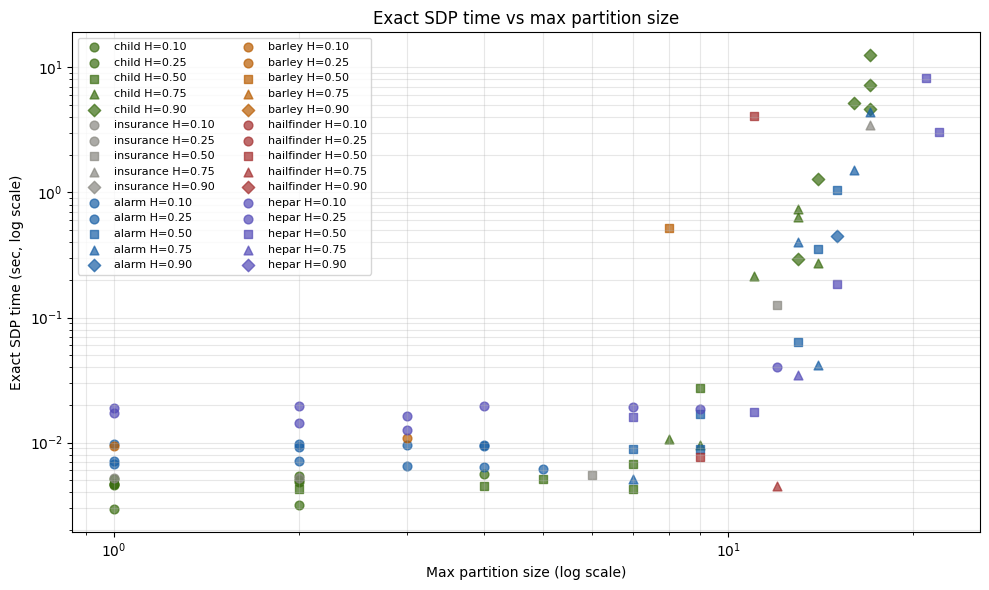

In [11]:
# plot time versus max partition size, with points colored by network and shaped by H_Ratio
fig, ax = plt.subplots(figsize=(10, 6))
for net in df['Network'].unique():
    for hr in df['H_Ratio'].unique():
        sub = df[(df['Network'] == net) & (df['H_Ratio'] == hr)]
        if len(sub) == 0:
            continue
        ax.scatter(sub['Max_Partition_Size'], sub['Exact_Time_sec'],
                   color=net_colors[net], marker=h_markers.get(hr, 'o'),
                   alpha=0.7, s=40, label=f"{net} H={hr:.2f}")
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Max partition size (log scale)')
ax.set_ylabel('Exact SDP time (sec, log scale)')
ax.set_title('Exact SDP time vs max partition size')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), fontsize=8, ncol=2)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

In [12]:
df.Exact_Mem_MB_Python.describe()

count       79.000000
mean       910.932556
std       2437.353492
min          0.088047
25%          0.143493
50%          0.307224
75%        128.472340
max      11533.060108
Name: Exact_Mem_MB_Python, dtype: float64

In [13]:
df.MCMC_Mem_MB_Python.describe()

count    109.000000
mean       0.277203
std        0.137888
min        0.061378
25%        0.123718
50%        0.284440
75%        0.349640
max        0.822220
Name: MCMC_Mem_MB_Python, dtype: float64

In [14]:
df.MCMC_Avg_Time_sec.describe()

count    109.000000
mean       1.639589
std        1.094182
min        0.572469
25%        0.991348
50%        1.171684
75%        2.177122
max        5.028582
Name: MCMC_Avg_Time_sec, dtype: float64

In [15]:
# Filter out any rows where the exact algorithm failed or timed out
df = df.dropna(subset=['Exact_Time_sec', 'MCMC_Avg_Time_sec'])

# Optional: If you have a 'Status' column indicating success
if 'Status' in df.columns:
    df = df[df['Status'] == 'OK']

# Assign colors dynamically based on the network
networks = df['Network'].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(networks)))
net_colors = {net: color for net, color in zip(networks, colors)}
c_list = [net_colors[n] for n in df['Network']]

# ──────────────────────────────────────────────────────────────────
# Plot 1: Time vs Max Tensor Size
# ──────────────────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 6))

ax1.scatter(df['Max_Tensor_Size'], df['Exact_Time_sec'], 
            c=c_list, alpha=0.7, marker='o', s=30)
ax1.scatter(df['Max_Tensor_Size'], df['MCMC_Avg_Time_sec'], 
            c=c_list, alpha=0.6, marker='s', s=50, edgecolors='black', linewidths=0.5)

ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Max Tensor Size (entries, log scale)', fontsize=11)
ax1.set_ylabel('Execution Time in seconds (log scale)', fontsize=11)
ax1.set_title('Execution Time vs. Complexity\n(Circles = Exact SDP, Squares = MCMC)', fontsize=13)

# Custom Legend
for net in networks:
    ax1.scatter([], [], color=net_colors[net], label=net, s=40)
ax1.legend(title='Network', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3, which='both')

fig1.tight_layout()
fig1.savefig('plot_1_time_vs_tensor.png', dpi=150)
plt.close(fig1)

# ──────────────────────────────────────────────────────────────────
# Plot 2: Memory (RSS) vs Max Tensor Size (With Log-Zero Fix)
# ──────────────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(8, 6))

eps = 1e-4  # Prevent log(0) from hiding data
ax2.scatter(df['Max_Tensor_Size'], df['Exact_Mem_MB_RSS'] + eps, 
            c=c_list, alpha=0.7, marker='o', s=30)
ax2.scatter(df['Max_Tensor_Size'], df['MCMC_Mem_MB_RSS'] + eps, 
            c=c_list, alpha=0.6, marker='s', s=50, edgecolors='black', linewidths=0.5)

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('Max Tensor Size (entries, log scale)', fontsize=11)
ax2.set_ylabel('Peak RSS Memory in MB (log scale)', fontsize=11)
ax2.set_title('Memory Consumption vs. Complexity\n(Circles = Exact SDP, Squares = MCMC)', fontsize=13)

for net in networks:
    ax2.scatter([], [], color=net_colors[net], label=net, s=40)
ax2.legend(title='Network', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.grid(True, alpha=0.3, which='both')

fig2.tight_layout()
fig2.savefig('plot_2_memory_vs_tensor.png', dpi=150)
plt.close(fig2)

# ──────────────────────────────────────────────────────────────────
# Plot 3: Direct Head-to-Head Time Comparison (Exact vs MCMC)
# ──────────────────────────────────────────────────────────────────
fig3, ax3 = plt.subplots(figsize=(7, 7))

ax3.scatter(df['Exact_Time_sec'], df['MCMC_Avg_Time_sec'], 
            c=c_list, alpha=0.7, edgecolors='black', linewidths=0.5, s=40)

# Add a y=x line. Points below this line mean MCMC is faster.
min_val = min(df['Exact_Time_sec'].min(), df['MCMC_Avg_Time_sec'].min()) * 0.5
max_val = max(df['Exact_Time_sec'].max(), df['MCMC_Avg_Time_sec'].max()) * 2.0
ax3.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.5, label='y = x (Equal Time)')

ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlim(min_val, max_val)
ax3.set_ylim(min_val, max_val)
ax3.set_xlabel('Exact Algorithm Time (sec)', fontsize=11)
ax3.set_ylabel('MCMC Algorithm Time (sec)', fontsize=11)
ax3.set_title('Head-to-Head Speed: Exact vs. MCMC\n(Points below dashed line = MCMC is faster)', fontsize=12)

# Dummy points for legend
handles, labels = ax3.get_legend_handles_labels()
for net in networks:
    handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=net_colors[net], markersize=8))
    labels.append(net)
ax3.legend(handles, labels, fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.grid(True, alpha=0.3, which='both')

fig3.tight_layout()
fig3.savefig('plot_3_head_to_head_time.png', dpi=150)
plt.close(fig3)

# ──────────────────────────────────────────────────────────────────
# Plot 4: Accuracy Trade-off (Absolute Error vs MCMC Time)
# ──────────────────────────────────────────────────────────────────
fig4, ax4 = plt.subplots(figsize=(8, 6))

# Epsilon for Error in case of perfect exact matches (0.0 error)
err_eps = 1e-6
ax4.scatter(df['MCMC_Avg_Time_sec'], df['Absolute_Error'] + err_eps, 
            c=c_list, alpha=0.7, edgecolors='black', linewidths=0.5, s=40)

ax4.set_xscale('log')
ax4.set_yscale('log')
ax4.set_xlabel('MCMC Algorithm Time (sec, log scale)', fontsize=11)
ax4.set_ylabel('Absolute Error (log scale)', fontsize=11)
ax4.set_title('Accuracy vs Computation Time for MCMC', fontsize=13)

for net in networks:
    ax4.scatter([], [], color=net_colors[net], label=net, s=40)
ax4.legend(title='Network', fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3, which='both')

# Add a horizontal line for 1% error tolerance
ax4.axhline(0.01, color='red', linestyle=':', alpha=0.7, label='1% Error Boundary')

fig4.tight_layout()
fig4.savefig('plot_4_accuracy_tradeoff.png', dpi=150)
plt.close(fig4)

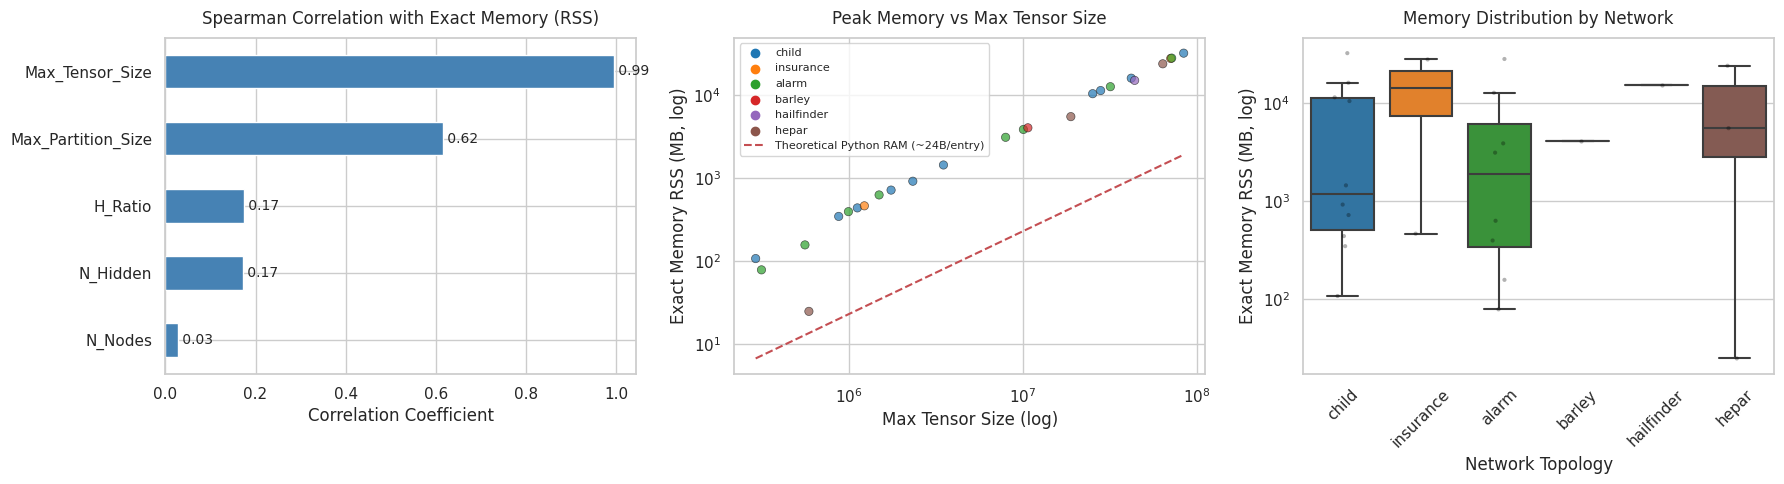

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr

df = df.dropna(subset=['Exact_Mem_MB_RSS', 'Max_Tensor_Size'])

# Filter out absolute zero memory if any exist (helps with log scales)
df = df[df['Exact_Mem_MB_RSS'] > 0]

# 2. Statistical Correlation (Spearman handles exponential relationships well)
features = ['Max_Tensor_Size', 'Max_Partition_Size', 'N_Hidden', 'H_Ratio', 'N_Nodes']
correlations = {}
for feat in features:
    # Check if column exists and has variance
    if feat in df.columns and df[feat].nunique() > 1:
        corr, p_val = spearmanr(df[feat], df['Exact_Mem_MB_RSS'])
        correlations[feat] = corr
        
# Sort by absolute correlation
corr_series = pd.Series(correlations).sort_values(ascending=True)

# 3. Setup Plotting
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 5))

# ── Panel 1: Feature Importance (Correlation) ─────────
ax1 = plt.subplot(1, 3, 1)
colors = ['steelblue' if val > 0 else 'indianred' for val in corr_series.values]
corr_series.plot(kind='barh', color=colors, ax=ax1)
ax1.set_title('Spearman Correlation with Exact Memory (RSS)', fontsize=12, pad=10)
ax1.set_xlabel('Correlation Coefficient')
for i, v in enumerate(corr_series.values):
    ax1.text(v, i, f" {v:.2f}", va='center', fontsize=10)
    
# ── Panel 2: Memory vs Max Tensor Size ─────────
ax2 = plt.subplot(1, 3, 2)
networks = df['Network'].unique()
palette = sns.color_palette("tab10", len(networks))

sns.scatterplot(data=df, x='Max_Tensor_Size', y='Exact_Mem_MB_RSS', 
                hue='Network', palette=palette, alpha=0.7, edgecolor='k', ax=ax2)

# Theoretical RAM line (Assuming 64-bit floats -> 8 bytes per entry)
# Plus ~3x overhead for Python objects, indices, and pgmpy Factor structures
x_vals = np.linspace(df['Max_Tensor_Size'].min(), df['Max_Tensor_Size'].max(), 100)
y_vals_theoretical = (x_vals * 8 * 3) / (1024 * 1024)  # Convert bytes to MB
ax2.plot(x_vals, y_vals_theoretical, 'r--', label='Theoretical Python RAM (~24B/entry)')

ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_title('Peak Memory vs Max Tensor Size', fontsize=12, pad=10)
ax2.set_xlabel('Max Tensor Size (log)')
ax2.set_ylabel('Exact Memory RSS (MB, log)')
ax2.legend(fontsize=8)

# ── Panel 3: Memory Density by Network Type ─────────
ax3 = plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Network', y='Exact_Mem_MB_RSS', 
            palette=palette, ax=ax3, showfliers=False)
sns.stripplot(data=df, x='Network', y='Exact_Mem_MB_RSS', 
                color='black', alpha=0.3, size=3, jitter=True, ax=ax3)

ax3.set_yscale('log')
ax3.set_title('Memory Distribution by Network', fontsize=12, pad=10)
ax3.set_xlabel('Network Topology')
ax3.set_ylabel('Exact Memory RSS (MB, log)')
ax3.tick_params(axis='x', rotation=45)

plt.tight_layout()
#plt.savefig('exact_memory_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()

In [17]:
from network_profiler import *
from pgmpy.utils import get_example_model

alarm_model = get_example_model('alarm')
child_model = get_example_model('child')

In [22]:
child_profile = profile_network(child_model)
alarm_profile = profile_network(alarm_model)

In [23]:
print_profile(alarm_profile)


Network: unknown

── Basic structure
  Nodes:              37
  Edges:              46
  Density:            0.034535
  Roots:              12
  Leaves:             11
  Connected comps:    1

── Depth / width
  Longest path:       10
  Levels:             11
  Avg degree:         2.49
  Max degree:         6
  Max in-degree:      4
  Max out-degree:     5

── Cardinality
  Avg cardinality:    2.84
  Max cardinality:    4
  % binary nodes:     35.1%
  Total CPD entries:  752
  Max CPD entries:    108

── Inference hardness
  Treewidth (UB):     4
  Moral graph density:0.097598
  Moral graph edges:  65

── SDP partition structure (5 random trials per ratio)
  H=10%: avg_max_partition=1.4 | avg_n_partitions=2.6 | avg_max_tensor=5
  H=25%: avg_max_partition=3.6 | avg_n_partitions=5.4 | avg_max_tensor=60
  H=50%: avg_max_partition=11.2 | avg_n_partitions=5.6 | avg_max_tensor=626746


In [19]:
df.sort_values("Exact_Mem_MB_RSS", ascending=False).head(10)

,Network,N_Nodes,Target_Bucket,H_Ratio,N_Hidden,Target_Node,Target_Value,Status,Wall_Hits,Attempts_OK,...,Exact_Mem_MB_RSS,Max_Partition_Size,Max_Tensor_Size,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,MCMC_Mem_MB_Python,MCMC_Mem_MB_RSS,Absolute_Error,Normalized_Entropy
27,child,20,0.8,0.90,17,Sick,no,OK,4,30,...,32357.5625,17.0,83980800.0,0.8427,0.000341,1.269306,0.274179,0.0,0.002100,0.939292
79,alarm,37,0.5,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,28204.3750,17.0,71663616.0,0.4551,0.000357,1.266520,0.333359,0.0,0.009400,0.436798
53,insurance,27,1.0,0.75,19,Theft,False,OK,768,30,...,27899.1250,17.0,70778880.0,1.0000,0.000000,1.398355,0.429642,0.0,0.000000,0.738294
163,hepar,70,0.7,0.50,34,hepatomegaly,absent,OK,460,29,...,24069.3750,21.0,63700992.0,0.6608,0.000572,1.515652,0.490829,0.0,0.009169,0.734842
25,child,20,0.5,0.90,17,Sick,no,OK,4,30,...,16136.0625,17.0,41990400.0,0.4922,0.000957,1.074952,0.284440,0.0,0.003725,0.939292
134,hailfinder,56,0.8,0.50,27,ScenRelAMCIN,CThruK,OK,306,492,...,15179.3750,11.0,43908480.0,0.8000,0.160000,2.425357,0.628784,0.0,0.047482,1.233303
82,alarm,37,0.9,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,12741.2500,16.0,31850496.0,0.8366,0.001558,1.131439,0.349640,0.0,0.018940,0.436798
28,child,20,0.9,0.90,17,Sick,no,OK,4,30,...,11443.6875,16.0,27993600.0,0.8632,0.000174,1.049461,0.290854,0.0,0.000242,0.939292
26,child,20,0.7,0.90,17,Sick,no,OK,4,30,...,10488.9375,17.0,25194240.0,0.6796,0.000869,1.024086,0.287298,0.0,0.007970,0.939292
162,hepar,70,0.5,0.50,34,hepatomegaly,absent,OK,460,29,...,5541.8750,22.0,18874368.0,0.4777,0.000218,1.340315,0.503876,0.0,0.003687,0.734842


In [20]:
df.sort_values("MCMC_Mem_MB_RSS", ascending=False).head(10)

,Network,N_Nodes,Target_Bucket,H_Ratio,N_Hidden,Target_Node,Target_Value,Status,Wall_Hits,Attempts_OK,...,Exact_Mem_MB_RSS,Max_Partition_Size,Max_Tensor_Size,MCMC_Mean_SDP,MCMC_Variance,MCMC_Avg_Time_sec,MCMC_Mem_MB_Python,MCMC_Mem_MB_RSS,Absolute_Error,Normalized_Entropy
18,child,20,0.4,0.75,14,Sick,no,OK,0,356,...,107.1875,11.0,291600.0,0.435400,0.000103,0.853375,0.294884,0.0,1.419841e-03,0.939292
73,alarm,37,0.5,0.50,18,HYPOVOLEMIA,FALSE,OK,1,241,...,3878.4375,15.0,10077696.0,0.548667,0.000070,2.848378,0.329824,0.0,7.697145e-03,0.436798
163,hepar,70,0.7,0.50,34,hepatomegaly,absent,OK,460,29,...,24069.3750,21.0,63700992.0,0.660800,0.000572,1.515652,0.490829,0.0,9.169287e-03,0.734842
162,hepar,70,0.5,0.50,34,hepatomegaly,absent,OK,460,29,...,5541.8750,22.0,18874368.0,0.477700,0.000218,1.340315,0.503876,0.0,3.686702e-03,0.734842
134,hailfinder,56,0.8,0.50,27,ScenRelAMCIN,CThruK,OK,306,492,...,15179.3750,11.0,43908480.0,0.800000,0.160000,2.425357,0.628784,0.0,4.748225e-02,1.233303
107,barley,48,1.0,0.50,23,pesticid,x_2,OK,746,54,...,4063.6250,8.0,10692000.0,1.000000,0.000000,1.140940,0.431707,0.0,1.110223e-16,1.419562
87,alarm,37,0.8,0.90,32,HYPOVOLEMIA,FALSE,OK,792,8,...,3118.7500,15.0,7962624.0,0.819500,0.001850,0.936513,0.353033,0.0,2.566201e-02,0.436798
83,alarm,37,1.0,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,156.6875,14.0,559872.0,1.000000,0.000000,0.948593,0.365723,0.0,0.000000e+00,0.436798
82,alarm,37,0.9,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,12741.2500,16.0,31850496.0,0.836600,0.001558,1.131439,0.349640,0.0,1.893967e-02,0.436798
80,alarm,37,0.7,0.75,27,HYPOVOLEMIA,FALSE,OK,574,174,...,78.3125,13.0,314928.0,0.747100,0.002794,0.886412,0.317085,0.0,2.669983e-02,0.436798
